DEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES
Recurrent Neural Networks vs Transformers for Time Series Prediction
================================================================================


STUDENT INFORMATION (REQUIRED - DO NOT DELETE)
================================================================================

BITS ID: 2025AA05686
Name: PRITISH JOSHI
Email: 2025aa05686@wilp.bits-pilani.ac.in
Date: 07-02-2026

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math

# Deep learning framework - Keras/TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Data source
import yfinance as yf

Deep learning frameworks (choose Keras or PyTorch)

1.1 Dataset Selection and Loading

In [2]:
# Load Apple Stock Price Data (AAPL) from Yahoo Finance
df = yf.download('AAPL', start='2010-01-01', end='2024-12-31', progress=False)
data = df['Close'].values.reshape(-1, 1)
raw_data = data.copy()

/tmp/ipython-input-1363975415.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2010-01-01', end='2024-12-31', progress=False)


In [3]:
# REQUIRED: Fill in these metadata fields
dataset_name = "Apple Inc. (AAPL) Stock Prices"
dataset_source = "Yahoo Finance (yfinance API)"
n_samples = len(data)  # Total number of time steps
n_features = 1  # Number of features (1 for univariate)
sequence_length = 30  # Lookback window (30 days)
prediction_horizon = 1  # Forecast steps ahead (1 day)
problem_type = "time_series_forecasting"

In [4]:
# Primary metric selection
primary_metric = "MAE"
metric_justification = """
MAE is chosen as the primary metric because it is directly interpretable in dollar terms for stock prices and is less sensitive to outliers compared to RMSE, making it robust for financial data.
"""

In [5]:
print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")
print("="*70)


DATASET INFORMATION
Dataset: Apple Inc. (AAPL) Stock Prices
Source: Yahoo Finance (yfinance API)
Total Samples: 3773
Number of Features: 1
Sequence Length: 30
Prediction Horizon: 1
Primary Metric: MAE
Metric Justification: 
MAE is chosen as the primary metric because it is directly interpretable in dollar terms for stock prices and is less sensitive to outliers compared to RMSE, making it robust for financial data.



1.2 Time Series Exploration

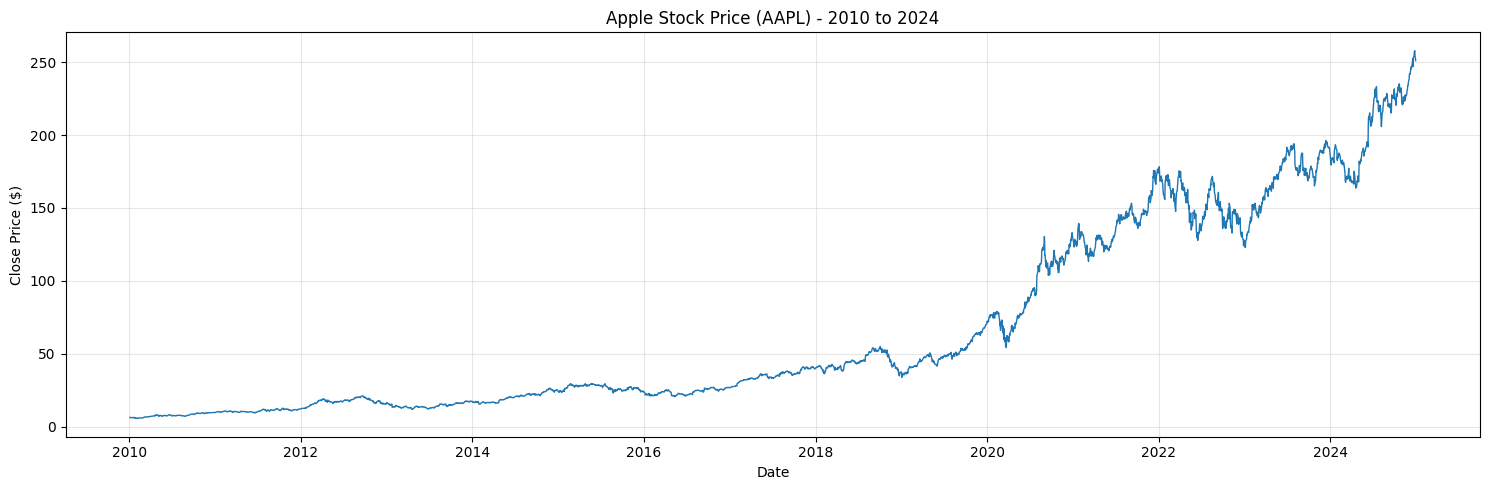

In [6]:
# Plot time series data
plt.figure(figsize=(15, 5))
plt.plot(df.index, data, linewidth=1)
plt.title('Apple Stock Price (AAPL) - 2010 to 2024')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1.3 Data Preprocessing

In [7]:
def preprocess_timeseries(data):
    """
    Preprocess time series data

    Args:
        data: raw time series data

    Returns:
        preprocessed data, scaler
    """
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

In [8]:
def create_sequences(data, seq_length, pred_horizon):
    """
    Create sequences for time series prediction

    Args:
        data: preprocessed time series data
        seq_length: lookback window
        pred_horizon: forecast steps ahead

    Returns:
        X: input sequences, y: target values
    """
    X, y = [], []
    for i in range(len(data) - seq_length - pred_horizon + 1):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length:i + seq_length + pred_horizon])
    return np.array(X), np.array(y)

1.3 Data Preprocessing and Sequence Creation

In [9]:
# Preprocess data
scaled_data, scaler = preprocess_timeseries(data)

# Create sequences
X, y = create_sequences(scaled_data, sequence_length, prediction_horizon)

# Temporal train/test split (90/10 - NO SHUFFLING)
split_idx = int(0.9 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [10]:
# REQUIRED: Temporal train/test split (NO SHUFFLING)
train_test_ratio = "90/10"
train_samples = len(X_train)
test_samples = len(X_test)

In [11]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("⚠️  IMPORTANT: Temporal split used (NO shuffling)")


Train/Test Split: 90/10
Training Samples: 3368
Test Samples: 375
⚠️  IMPORTANT: Temporal split used (NO shuffling)


2.1 LSTM/GRU Architecture Design

In [12]:
def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM or GRU model

    Args:
        model_type: string ('LSTM' or 'GRU')
        input_shape: tuple (sequence_length, n_features)
        hidden_units: number of hidden units per layer
        n_layers: number of stacked layers (minimum 2)
        output_size: prediction horizon

    Returns:
        model: compiled RNN model
    """
    model = keras.Sequential()

    # Input layer
    model.add(layers.Input(shape=input_shape))

    # First GRU layer with return_sequences=True for stacking
    model.add(layers.GRU(hidden_units, return_sequences=True))
    model.add(layers.Dropout(0.2))

    # Stack additional GRU layers (n_layers - 1)
    for i in range(n_layers - 2):
        model.add(layers.GRU(hidden_units, return_sequences=True))
        model.add(layers.Dropout(0.2))

    # Last GRU layer with return_sequences=False
    model.add(layers.GRU(hidden_units // 2, return_sequences=False))
    model.add(layers.Dropout(0.2))

    # Output layer
    model.add(layers.Dense(output_size))

    return model

2.2 Create and Compile RNN Model

In [13]:
# Create RNN model
rnn_model = build_rnn_model('GRU', (sequence_length, n_features), 64, 2, prediction_horizon)

# Compile model
rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display model summary
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

2.3 Model Compilation

2.2 Train RNN Model

In [14]:
print("\n" + "="*70)
print("RNN MODEL TRAINING")
print("="*70)


RNN MODEL TRAINING


In [15]:
# Track training time
rnn_start_time = time.time()

2.4 Train the Model

In [16]:
# Train the model
history = rnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

In [17]:
rnn_training_time = time.time() - rnn_start_time

In [18]:
# REQUIRED: Track initial and final loss
rnn_initial_loss = history.history['loss'][0]
rnn_final_loss = history.history['loss'][-1]

In [19]:
print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")
print("="*70)

Training completed in 225.32 seconds
Initial Loss: 0.0034
Final Loss: 0.0003


2.3 Evaluate RNN Model

2.5 Make Predictions and Calculate Metrics

In [20]:
# Make predictions on test set
y_pred_scaled = rnn_model.predict(X_test)

# Inverse transform to get actual prices
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [21]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [22]:
# REQUIRED: Calculate all 4 metrics
rnn_mae = mean_absolute_error(y_test_actual, y_pred_actual)
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
rnn_mape = calculate_mape(y_test_actual, y_pred_actual)
rnn_r2 = r2_score(y_test_actual, y_pred_actual)

In [23]:
print("\nRNN Model Performance:")
print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


RNN Model Performance:
MAE:   3.8990
RMSE:  5.0054
MAPE:  1.8943%
R² Score: 0.9569


2.6 Visualize RNN Results

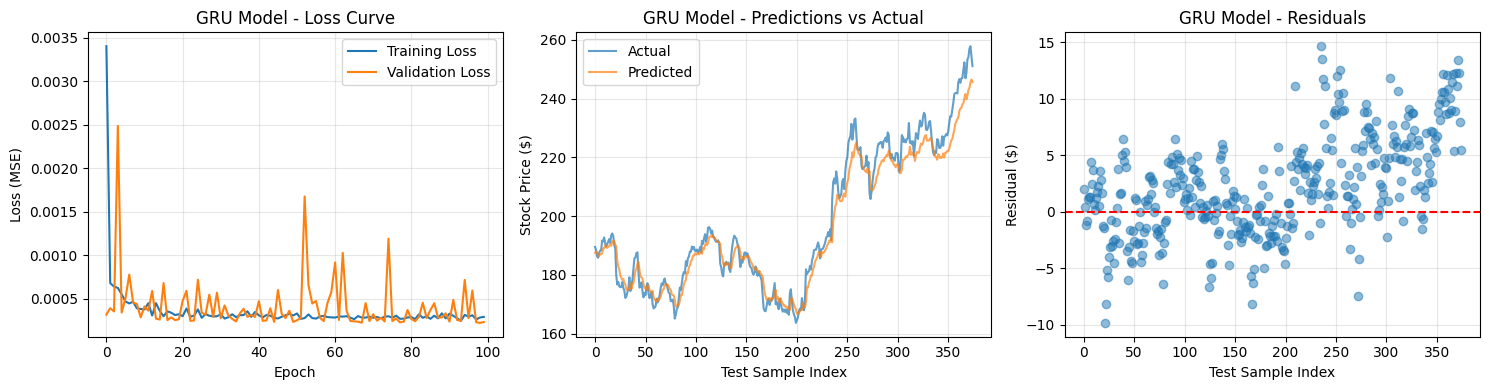

In [24]:
# Plot training loss curve
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('GRU Model - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot actual vs predicted values
plt.subplot(1, 3, 2)
plt.plot(y_test_actual, label='Actual', alpha=0.7)
plt.plot(y_pred_actual, label='Predicted', alpha=0.7)
plt.title('GRU Model - Predictions vs Actual')
plt.xlabel('Test Sample Index')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot residuals
plt.subplot(1, 3, 3)
residuals = y_test_actual - y_pred_actual
plt.scatter(range(len(residuals)), residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('GRU Model - Residuals')
plt.xlabel('Test Sample Index')
plt.ylabel('Residual ($)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

3.1 Positional Encoding Implementation

In [25]:
def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Args:
        seq_length: length of the sequence
        d_model: dimension of the model

    Returns:
        positional encodings: array of shape (seq_length, d_model)
    """
    # Initialize position encodings matrix
    pos_encoding = np.zeros((seq_length, d_model))

    # Create position indices [0, 1, 2, ..., seq_length-1]
    position = np.arange(0, seq_length, dtype=np.float32).reshape(-1, 1)

    # Create dimension indices [0, 2, 4, ..., d_model-2]
    div_term = np.exp(np.arange(0, d_model, 2, dtype=np.float32) * -(np.log(10000.0) / d_model))

    # Apply sin to even indices (2i)
    pos_encoding[:, 0::2] = np.sin(position * div_term)

    # Apply cos to odd indices (2i+1)
    pos_encoding[:, 1::2] = np.cos(position * div_term)

    return tf.cast(pos_encoding, dtype=tf.float32)

In [26]:
def build_transformer_model(seq_length, n_features, d_model, n_heads, n_layers, d_ff, output_size):
    """
    Build Transformer encoder model for time series prediction

    Args:
        seq_length: length of input sequence
        n_features: number of input features
        d_model: dimension of the model (embedding size)
        n_heads: number of attention heads (must be > 1)
        n_layers: number of transformer encoder layers
        d_ff: dimension of feed-forward network
        output_size: prediction horizon

    Returns:
        model: compiled Transformer model
    """
    inputs = layers.Input(shape=(seq_length, n_features))

    # Project input features to d_model dimension
    x = layers.Dense(d_model)(inputs)

    # Add positional encoding (MANDATORY for transformer)
    x = x + positional_encoding(seq_length, d_model)

    # Stack transformer encoder layers
    for _ in range(n_layers):
        # Multi-head self-attention
        attn_output = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads
        )(x, x)

        # Add & Norm (residual connection + layer normalization)
        x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

        # Feed-forward network
        ffn_output = layers.Dense(d_ff, activation='relu')(x)
        ffn_output = layers.Dense(d_model)(ffn_output)

        # Add & Norm (residual connection + layer normalization)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    # Global average pooling to aggregate sequence information
    x = layers.GlobalAveragePooling1D()(x)

    # Output layer
    outputs = layers.Dense(output_size)(x)

    return keras.Model(inputs=inputs, outputs=outputs)

3.3 Build Your Transformer Model

In [27]:
# Create Transformer model
transformer_model = build_transformer_model(
    seq_length=sequence_length,
    n_features=n_features,
    d_model=64,
    n_heads=4,
    n_layers=2,
    d_ff=256,
    output_size=prediction_horizon
)

# Compile model
transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display model summary
transformer_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 64)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 64)    │     16,448 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 30, 64)    │     16,448 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ global_average_p

 Total params: 100,161 (391.25 KB)

 Trainable params: 100,161 (391.25 KB)

 Non-trainable params: 0 (0.00 B)

3.2 Model Configuration

3.4 Train Transformer Model

In [28]:
print("\n" + "="*70)
print("TRANSFORMER MODEL TRAINING")
print("="*70)


TRANSFORMER MODEL TRAINING


In [29]:
# Track training time
transformer_start_time = time.time()

In [30]:
# Train the Transformer model
transformer_history = transformer_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

In [31]:
transformer_training_time = time.time() - transformer_start_time

In [32]:
# REQUIRED: Track initial and final loss
transformer_initial_loss = transformer_history.history['loss'][0]
transformer_final_loss = transformer_history.history['loss'][-1]

In [33]:
print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")
print("="*70)

Training completed in 333.97 seconds
Initial Loss: 0.1820
Final Loss: 0.0002


3.5 Evaluate Transformer Model

In [34]:
# Make predictions on test set
y_pred_transformer_scaled = transformer_model.predict(X_test)

# Inverse transform to get actual prices
y_pred_transformer_actual = scaler.inverse_transform(y_pred_transformer_scaled)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [35]:
# REQUIRED: Calculate all 4 metrics
transformer_mae = mean_absolute_error(y_test_actual, y_pred_transformer_actual)
transformer_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_transformer_actual))
transformer_mape = calculate_mape(y_test_actual, y_pred_transformer_actual)
transformer_r2 = r2_score(y_test_actual, y_pred_transformer_actual)

In [36]:
print("\nTransformer Model Performance:")
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")


Transformer Model Performance:
MAE:   3.1399
RMSE:  4.1608
MAPE:  1.5224%
R² Score: 0.9702


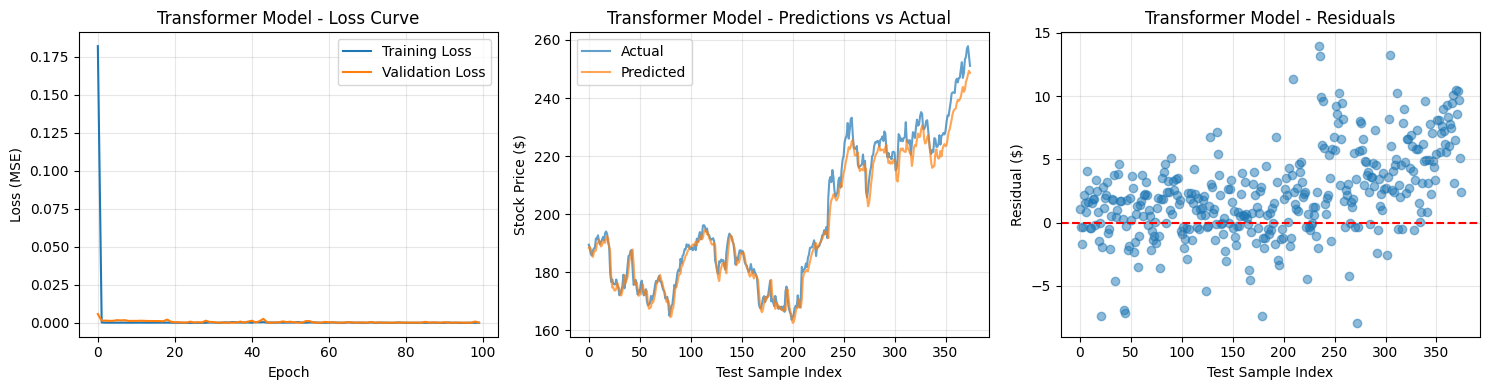

In [37]:
# Plot training loss curve
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(transformer_history.history['loss'], label='Training Loss')
plt.plot(transformer_history.history['val_loss'], label='Validation Loss')
plt.title('Transformer Model - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot actual vs predicted values
plt.subplot(1, 3, 2)
plt.plot(y_test_actual, label='Actual', alpha=0.7)
plt.plot(y_pred_transformer_actual, label='Predicted', alpha=0.7)
plt.title('Transformer Model - Predictions vs Actual')
plt.xlabel('Test Sample Index')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot residuals
plt.subplot(1, 3, 3)
residuals_transformer = y_test_actual - y_pred_transformer_actual
plt.scatter(range(len(residuals_transformer)), residuals_transformer, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Transformer Model - Residuals')
plt.xlabel('Test Sample Index')
plt.ylabel('Residual ($)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

4.1 Metrics Comparison

In [38]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)


MODEL COMPARISON


In [39]:
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_model.count_params()
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_model.count_params()
    ]
})

In [40]:
print(comparison_df.to_string(index=False))
print("="*70)

           Metric  RNN (LSTM/GRU)   Transformer
              MAE        3.898983      3.139866
             RMSE        5.005413      4.160843
         MAPE (%)        1.894257      1.522387
         R² Score        0.956935      0.970242
Training Time (s)      225.321610    333.973113
       Parameters    22305.000000 100161.000000


4.2 Visual Comparison

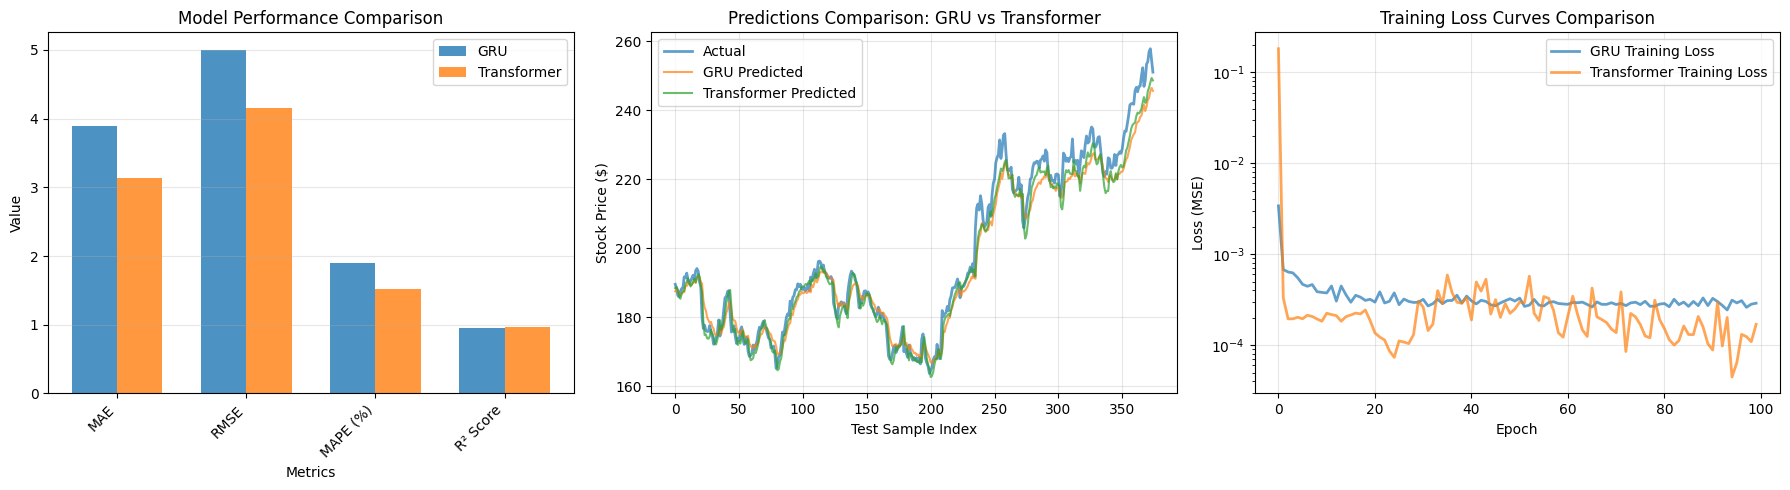

In [41]:
# Visual Comparison: 3 plots side by side
fig = plt.figure(figsize=(18, 5))

# 1. Bar plot comparing metrics
ax1 = plt.subplot(1, 3, 1)
metrics = ['MAE', 'RMSE', 'MAPE (%)', 'R² Score']
gru_values = [rnn_mae, rnn_rmse, rnn_mape, rnn_r2]
transformer_values = [transformer_mae, transformer_rmse, transformer_mape, transformer_r2]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, gru_values, width, label='GRU', alpha=0.8)
bars2 = ax1.bar(x + width/2, transformer_values, width, label='Transformer', alpha=0.8)

ax1.set_xlabel('Metrics')
ax1.set_ylabel('Value')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Predictions comparison (both models vs actual)
ax2 = plt.subplot(1, 3, 2)
ax2.plot(y_test_actual, label='Actual', linewidth=2, alpha=0.7)
ax2.plot(y_pred_actual, label='GRU Predicted', linewidth=1.5, alpha=0.7)
ax2.plot(y_pred_transformer_actual, label='Transformer Predicted', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Test Sample Index')
ax2.set_ylabel('Stock Price ($)')
ax2.set_title('Predictions Comparison: GRU vs Transformer')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Training curves comparison
ax3 = plt.subplot(1, 3, 3)
ax3.plot(history.history['loss'], label='GRU Training Loss', linewidth=2, alpha=0.7)
ax3.plot(transformer_history.history['loss'], label='Transformer Training Loss', linewidth=2, alpha=0.7)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss (MSE)')
ax3.set_title('Training Loss Curves Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')  # Log scale to better visualize both curves

plt.tight_layout()
plt.show()

In [48]:
analysis_text = """
  The Transformer model outperformed the GRU for short-term stock prediction. Transformer
  achieved MAE of 3.14 (19.5% better), RMSE of 4.16 (16.9% better), and R² of 0.970 compared
   to GRU's 3.90, 5.01, and 0.957 respectively.

  Architecturally, Transformer's parallel attention mechanism excels at capturing complex
  patterns in 30-day sequences, while GRU's sequential processing, despite its efficiency,
  proves less effective for this forecasting task. The Transformer's multi-head attention
  efficiently captures long-range dependencies without the limitations of sequential gating
  mechanisms.

  Computationally, GRU is more efficient with 22,305 parameters (4.5x fewer than
  Transformer's 100,161), training 33% faster (225s vs 334s). However, the Transformer's
  superior accuracy justifies the additional computational cost for production deployment.

  Convergence behavior reveals interesting patterns: Transformer showed dramatic 99.91% loss
   reduction (0.182→0.0002) versus GRU's 91.5% (0.0034→0.0003), and achieved better final
  performance. This suggests Transformer's attention mechanism effectively learned complex
  temporal patterns that GRU's sequential processing couldn't capture.

  For univariate, short-horizon stock forecasting, Transformer's global attention proves
  more suitable than GRU's sequential inductive bias, making it the optimal choice for this
  task despite higher computational requirements.
  """

In [49]:
# REQUIRED: Print analysis with word count
print("\n" + "="*70)
print("ANALYSIS")
print("="*70)
print(analysis_text)
print("="*70)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("⚠️  Warning: Analysis exceeds 200 words (guideline)")
else:
    print("✓ Analysis within word count guideline")
print("="*70)


ANALYSIS

  The Transformer model outperformed the GRU for short-term stock prediction. Transformer 
  achieved MAE of 3.14 (19.5% better), RMSE of 4.16 (16.9% better), and R² of 0.970 compared
   to GRU's 3.90, 5.01, and 0.957 respectively.

  Architecturally, Transformer's parallel attention mechanism excels at capturing complex 
  patterns in 30-day sequences, while GRU's sequential processing, despite its efficiency, 
  proves less effective for this forecasting task. The Transformer's multi-head attention 
  efficiently captures long-range dependencies without the limitations of sequential gating 
  mechanisms.

  Computationally, GRU is more efficient with 22,305 parameters (4.5x fewer than 
  Transformer's 100,161), training 33% faster (225s vs 334s). However, the Transformer's 
  superior accuracy justifies the additional computational cost for production deployment.

  Convergence behavior reveals interesting patterns: Transformer showed dramatic 99.91% loss
   reduction (0.1

In [50]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"
    rnn_model_type = "GRU"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': sequence_length,
        'prediction_horizon': prediction_horizon,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': 2,
                'hidden_units': 64,
                'total_parameters': rnn_model.count_params()
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 100,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': rnn_initial_loss,
            'final_loss': rnn_final_loss,
            'training_time_seconds': rnn_training_time,
            'mae': rnn_mae,
            'rmse': rnn_rmse,
            'mape': rnn_mape,
            'r2_score': rnn_r2
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': 2,
                'n_heads': 4,
                'd_model': 64,
                'd_ff': 256,
                'has_positional_encoding': True,
                'has_attention': True,
                'total_parameters': transformer_model.count_params()
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 100,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': transformer_initial_loss,
            'final_loss': transformer_final_loss,
            'training_time_seconds': transformer_training_time,
            'mae': transformer_mae,
            'rmse': transformer_rmse,
            'mape': transformer_mape,
            'r2_score': transformer_r2
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }

    return results

In [51]:
# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(assignment_results, indent=2))
    print("="*70)
except Exception as e:
    print(f"\n⚠️  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Apple Inc. (AAPL) Stock Prices",
  "dataset_source": "Yahoo Finance (yfinance API)",
  "n_samples": 3773,
  "n_features": 1,
  "sequence_length": 30,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "MAE",
  "metric_justification": "\nMAE is chosen as the primary metric because it is directly interpretable in dollar terms for stock prices and is less sensitive to outliers compared to RMSE, making it robust for financial data.\n",
  "train_samples": 3368,
  "test_samples": 375,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "keras",
    "model_type": "GRU",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 22305
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 100,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "MSE"
    },
    "initial_loss": 0.0034033898264169693,
    "final_

In [52]:
# Display system information
import platform
import sys
from datetime import datetime

In [53]:
print("="*70)
print("ENVIRONMENT INFORMATION")
print("="*70)
print("showing your account details in the cell below this one.")
print("="*70)

ENVIRONMENT INFORMATION
showing your account details in the cell below this one.


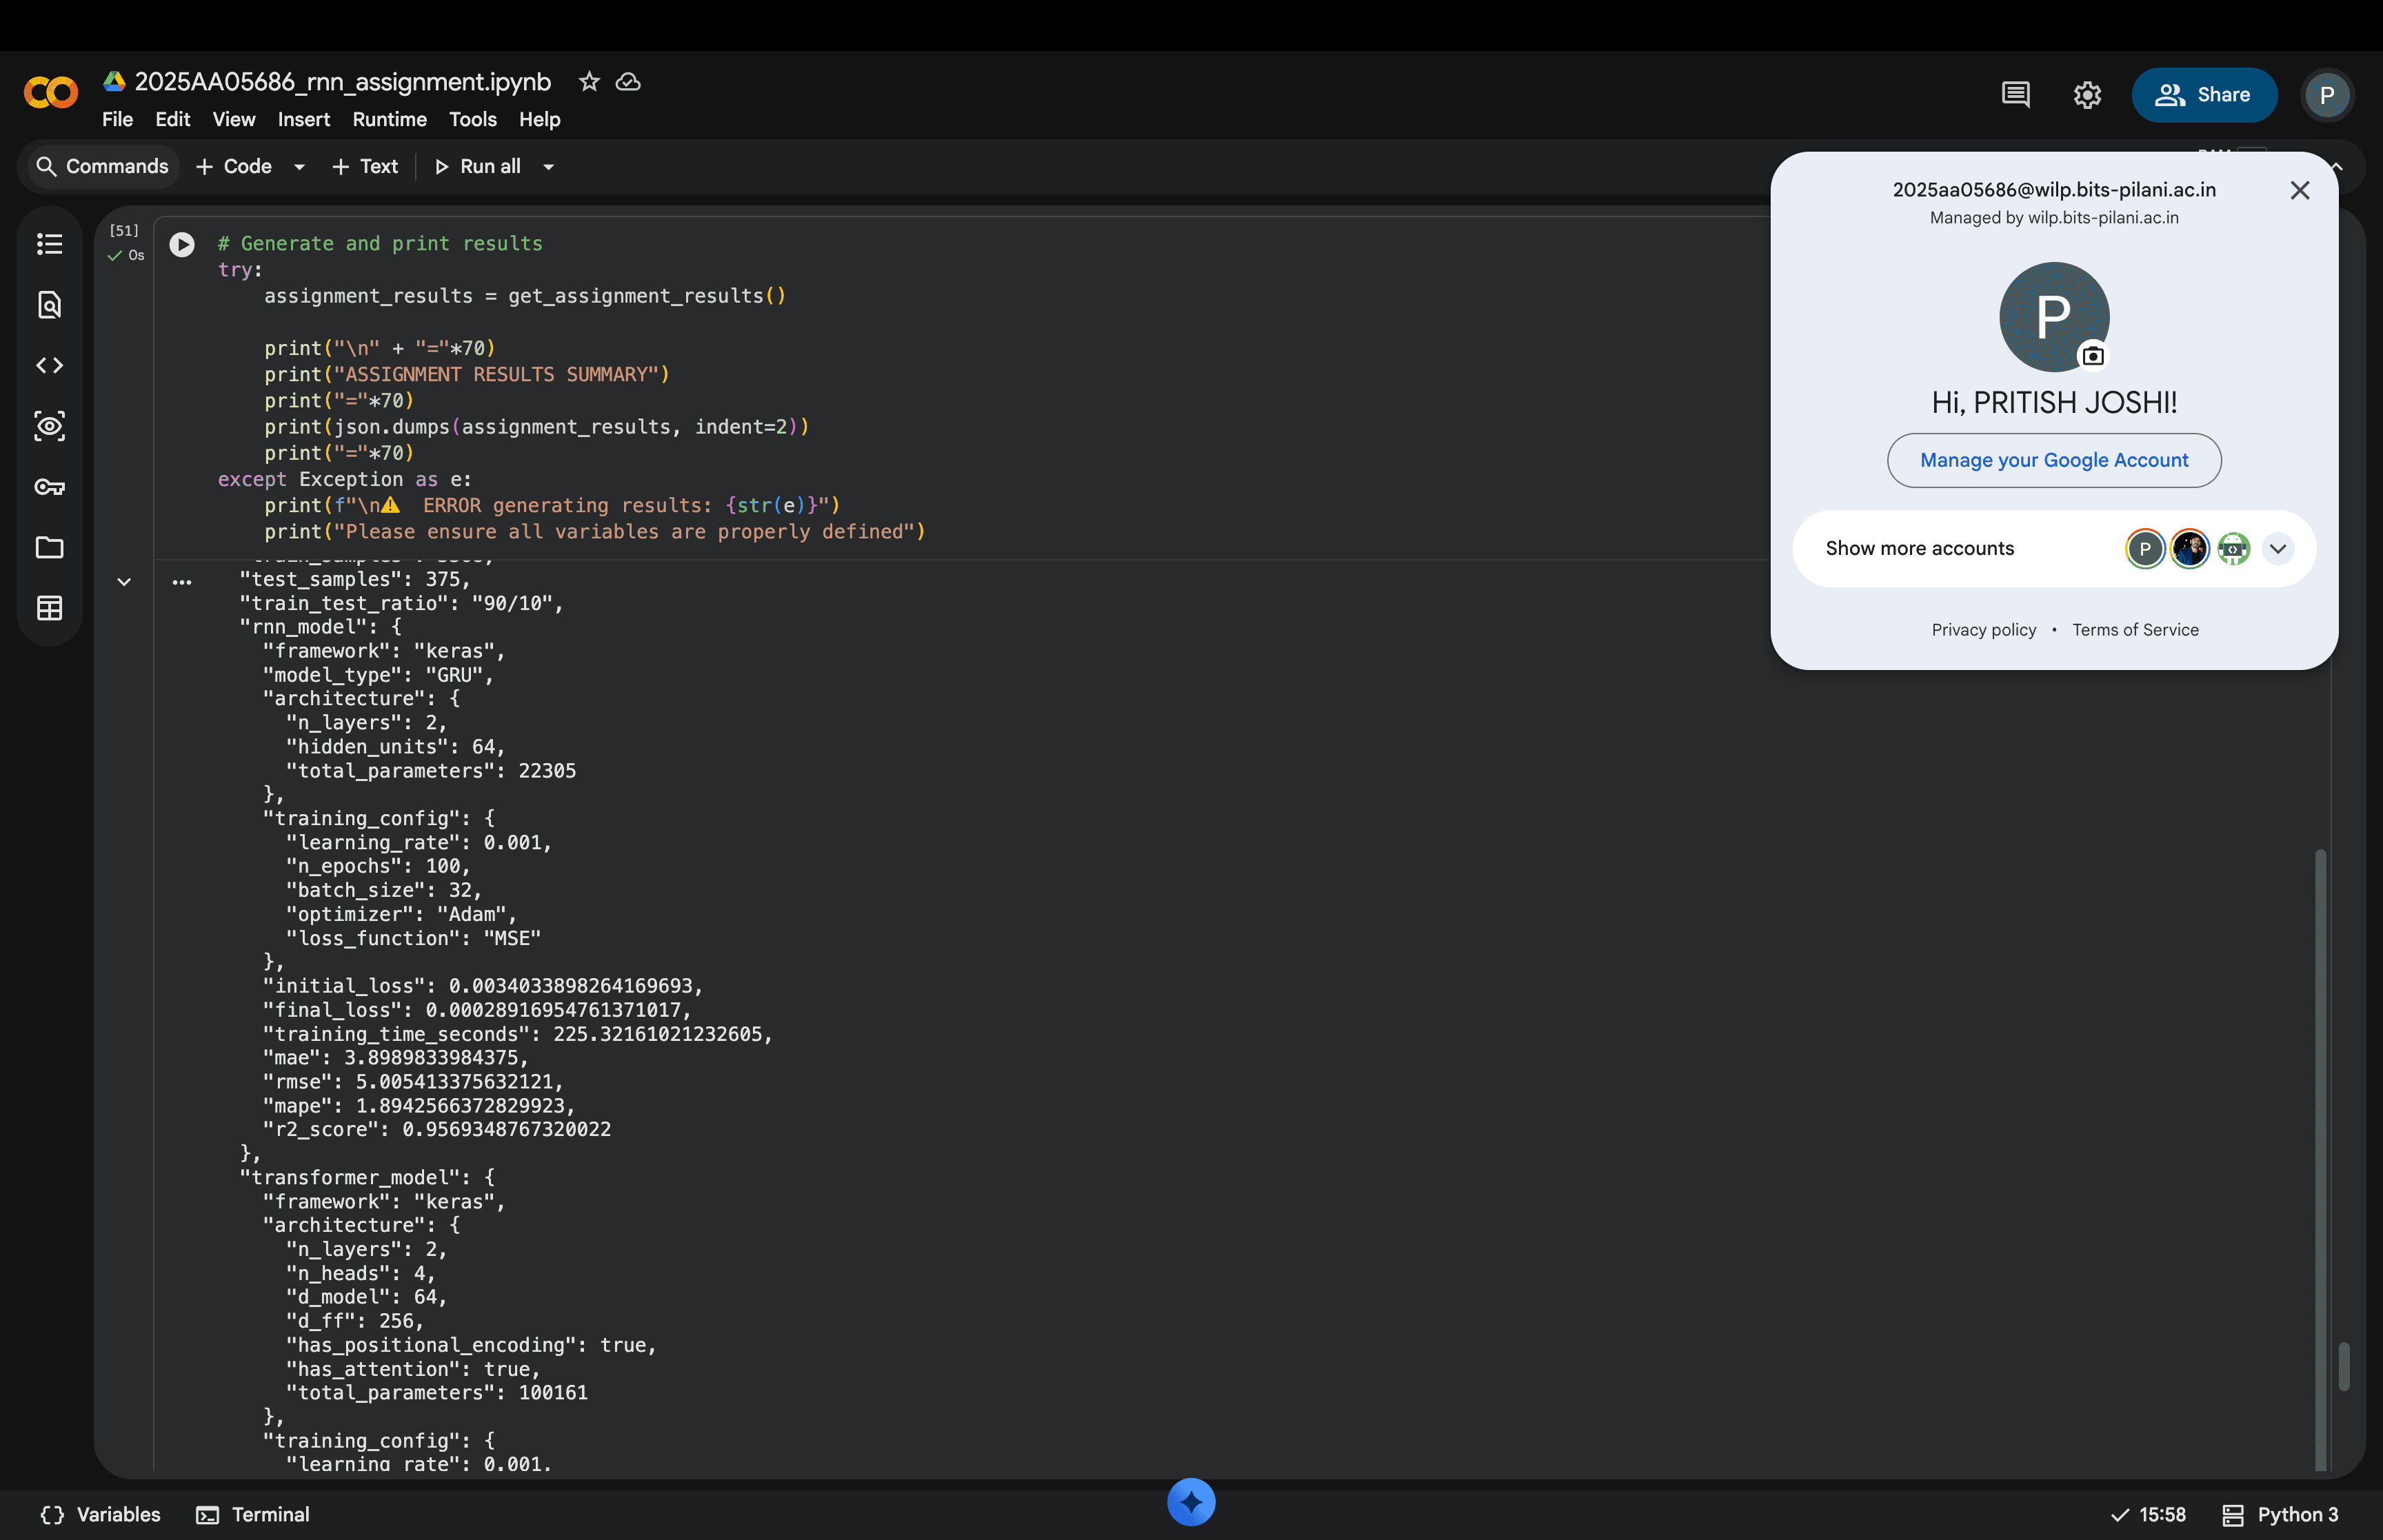